# imports

In [1]:
# imports

import os
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer

%matplotlib inline
pd.options.mode.chained_assignment = None  # default='warn

pd.set_option('display.max_rows', 750)
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', None)

In [2]:
#imp_med = SimpleImputer(missing_values=np.nan, strategy='median')
#imp_mean = SimpleImputer(missing_values=np.nan, strategy='mean')

In [3]:
path = './data/'
csv_path = path + 'to_input_openfoodfacts.csv'
#csv_path = path + 'en.openfoodfacts.org.products.csv'
sm_df = pd.read_csv(csv_path, low_memory=False)

# Dataframe info

## functions

In [4]:
def get_df_columns_na(df):
    nan_values = df.isnull().sum()
    nan_percent = nan_values /df.shape[0]*100
    nan_info = pd.concat([nan_values,nan_percent],axis=1)
    nan_info.columns = ['count', 'null_percent']
    nan_info = nan_info.sort_values(by='null_percent',ascending=True)
    return nan_info

In [5]:
def plot_df_xy(df, x_val, y_val, height_val = 20, width_val = 13):
    sns.catplot(data=df, x= x_val, y= y_val, kind="bar", height=height_val, aspect=width_val/height_val)
    sns.set(rc={'figure.figsize':(width_val,height_val)})
    plt.xticks(rotation=70)
    plt.tight_layout()

In [6]:
def show_nulls(df, display=False):
    df_nulls = get_df_columns_na(df).sort_values(by='null_percent',ascending=False)
    print(df_nulls)
    if display == True:
        plot_df_xy(df_nulls.reset_index(), 'null_percent', 'index', 7)

In [7]:
def boxplot_nums_old(df, num_cols, energy_cols, scores_cols):
    sns.set(rc={'figure.figsize':(11.7,8.27)})
    fig, ax  = plt.subplots(1,3, gridspec_kw={'width_ratios': [8, 1, 1]})
    sns.boxplot(data=df[num_cols], ax=ax[0])
    sns.boxplot(data=df[energy_cols], ax=ax[1])
    sns.boxplot(data=df[scores_cols], ax=ax[2])
    ax[0].set_xticklabels(ax[0].get_xticklabels(),rotation=55)
    ax[1].set_xticklabels(ax[1].get_xticklabels(),rotation=55)
    ax[2].set_xticklabels(ax[2].get_xticklabels(),rotation=55)
    plt.show()

In [8]:
def boxplot_nums(df, cols_lists):
    sns.set(rc={'figure.figsize':(11.7,8.27)})
    
    col_lists_len = len(cols_lists)
    all_lists_len = []
    iter = 0
    for i in cols_lists:
        all_lists_len.append(len(i))
    
    fig, ax  = plt.subplots(1,col_lists_len, gridspec_kw={'width_ratios': all_lists_len})
    
    for i in cols_lists:
        sns.boxplot(data=df[i], ax=ax[iter])
        ax[iter].set_xticklabels(ax[iter].get_xticklabels(),rotation=55)
        iter+=1
    
    plt.show()

## General distribution / NaNs 

In [9]:
sm_df.shape

(46254, 15)

In [10]:
sm_df.head()

,code,nutrition_grade_fr,nutrition-score-fr_100g,proteins_100g,energy_100g,salt_100g,sodium_100g,sugars_100g,saturated-fat_100g,product_name,fiber_100g,fat_100g,carbohydrates_100g,pnns_groups_2,pnns_groups_1
0,10187319,d,14.0,0.6,1753.0,0.0100,0.003937,87.7,0.8,Mini Confettis,0.9,NaN,NaN,NaN,NaN
1,10207260,d,14.0,9.5,2406.0,0.0030,0.001181,50.3,2.9,Praliné Amande Et Noisette,3.9,NaN,NaN,NaN,NaN
2,40608754,e,13.0,0.0,177.0,0.0254,0.010000,10.4,0.0,"Pepsi, Nouveau goût !",0.0,0.0,10.4,Sweetened beverages,Beverages
3,69161025,d,15.0,7.5,1079.0,0.8000,0.314961,1.0,11.0,Tarte Poireaux Et Lardons,1.4,NaN,NaN,NaN,NaN
4,87177756,e,13.0,0.0,177.0,0.1000,0.039370,10.4,0.0,7Up,NaN,0.0,10.4,Sweetened beverages,Beverages


In [11]:
sm_df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46254 entries, 0 to 46253
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   code                     46254 non-null  int64  
 1   nutrition_grade_fr       46254 non-null  object 
 2   nutrition-score-fr_100g  36796 non-null  float64
 3   proteins_100g            46187 non-null  float64
 4   energy_100g              46015 non-null  float64
 5   salt_100g                46186 non-null  float64
 6   sodium_100g              46187 non-null  float64
 7   sugars_100g              46184 non-null  float64
 8   saturated-fat_100g       46186 non-null  float64
 9   product_name             46254 non-null  object 
 10  fiber_100g               34517 non-null  float64
 11  fat_100g                 29410 non-null  float64
 12  carbohydrates_100g       29364 non-null  float64
 13  pnns_groups_2            27834 non-null  object 
 14  pnns_groups_1         

In [12]:
sm_df.describe()

,code,nutrition-score-fr_100g,proteins_100g,energy_100g,salt_100g,sodium_100g,sugars_100g,saturated-fat_100g,fiber_100g,fat_100g,carbohydrates_100g
count,4.625400e+04,36796.000000,46187.000000,46015.000000,46186.000000,46187.000000,46184.000000,46186.000000,34517.000000,29410.000000,29364.000000
mean,3.819760e+12,9.375068,8.002255,902.814028,1.030939,0.406938,8.410142,4.265709,2.082982,9.407097,16.340414
std,4.428525e+12,7.276457,8.175554,666.120119,2.220297,0.903142,14.188582,7.076040,4.110923,12.654028,20.163020
min,1.756000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.248830e+12,3.000000,1.500000,345.500000,0.080000,0.031496,0.800000,0.200000,0.000000,1.000000,2.500000
50%,3.329770e+12,9.000000,5.800000,751.000000,0.650000,0.255906,2.900000,1.400000,1.000000,4.200000,9.400000
75%,3.608581e+12,15.000000,12.000000,1403.000000,1.300000,0.511811,10.000000,5.000000,2.600000,12.900000,20.400000
max,3.661112e+14,36.000000,90.000000,3761.000000,68.200000,49.212598,100.000000,100.000000,100.000000,92.000000,100.000000


In [13]:
sm_df.columns.to_list()

['code',
 'nutrition_grade_fr',
 'nutrition-score-fr_100g',
 'proteins_100g',
 'energy_100g',
 'salt_100g',
 'sodium_100g',
 'sugars_100g',
 'saturated-fat_100g',
 'product_name',
 'fiber_100g',
 'fat_100g',
 'carbohydrates_100g',
 'pnns_groups_2',
 'pnns_groups_1']

In [14]:
sm_num_cols = ['fat_100g', 'saturated-fat_100g',
               'carbohydrates_100g', 'sugars_100g', 'proteins_100g', 
               'salt_100g','sodium_100g',
               'fiber_100g']
energy_cols = ['energy_100g']
scores_cols = ['nutrition-score-fr_100g'
               #'ecoscore_grade'
              ]

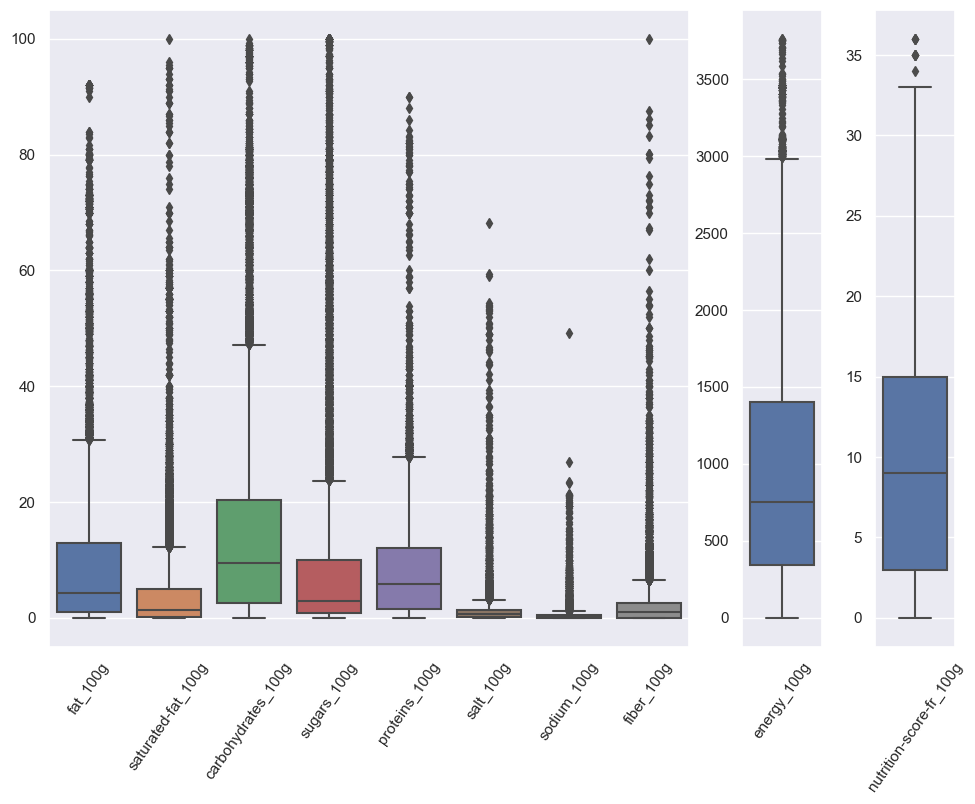

In [15]:
boxplot_nums(sm_df, [sm_num_cols, energy_cols, scores_cols])

In [16]:
## initial (2 282 517, 186)

sm_df.shape

(46254, 15)

In [17]:
#sm_df.isna().sum()

In [18]:
show_nulls(sm_df)

                         count  null_percent
pnns_groups_1            18508     40.013837
pnns_groups_2            18420     39.823583
carbohydrates_100g       16890     36.515761
fat_100g                 16844     36.416310
fiber_100g               11737     25.375103
nutrition-score-fr_100g   9458     20.447961
energy_100g                239      0.516712
sugars_100g                 70      0.151338
salt_100g                   68      0.147014
saturated-fat_100g          68      0.147014
proteins_100g               67      0.144852
sodium_100g                 67      0.144852
code                         0      0.000000
nutrition_grade_fr           0      0.000000
product_name                 0      0.000000


## Categories / "unknown"

In [19]:
main_cats = sm_df['pnns_groups_1'].unique()
main_cats

array([nan, 'Beverages', 'Fruits and vegetables', 'Salty snacks',
       'Composite foods', 'Fat and sauces', 'Sugary snacks',
       'Milk and dairy products', 'Cereals and potatoes',
       'Fish Meat Eggs'], dtype=object)

In [20]:
sm_df['pnns_groups_1'].value_counts()

pnns_groups_1
Composite foods            4763
Milk and dairy products    4725
Fish Meat Eggs             4444
Beverages                  3789
Cereals and potatoes       3465
Fruits and vegetables      2741
Fat and sauces             2007
Sugary snacks              1231
Salty snacks                581
Name: count, dtype: int64

In [21]:
all_cats = sm_df['pnns_groups_1'].unique().tolist()
all_cats

[nan,
 'Beverages',
 'Fruits and vegetables',
 'Salty snacks',
 'Composite foods',
 'Fat and sauces',
 'Sugary snacks',
 'Milk and dairy products',
 'Cereals and potatoes',
 'Fish Meat Eggs']

In [22]:
all_cols = sm_df.columns
all_cols

Index(['code', 'nutrition_grade_fr', 'nutrition-score-fr_100g',
       'proteins_100g', 'energy_100g', 'salt_100g', 'sodium_100g',
       'sugars_100g', 'saturated-fat_100g', 'product_name', 'fiber_100g',
       'fat_100g', 'carbohydrates_100g', 'pnns_groups_2', 'pnns_groups_1'],
      dtype='object')

In [23]:
main_cats = ['fat_100g', 'salt_100g']
complementary_cats = ['saturated-fat_100g','sodium_100g']

In [24]:
final_cats = [c for c in all_cols if c not in main_cats+complementary_cats]
final_cats

In [25]:
all_cols

In [26]:
num_cols = sm_df.columns[sm_df.dtypes == 'float64']
num_cols

# Inputing

## categories : most frequent

In [27]:
sm_df['pnns_groups_1'].value_counts()

In [28]:
sm_df.shape

In [29]:
## categorical pnn1 

## inputing valeur vides avec valeur plus fréQUENTE / SIMPLE IMPUTER _ strategy most _frequent
# SimpleImputer(strategy="most_frequent")

In [30]:
from sklearn.impute import SimpleImputer

In [31]:
imp_fre = SimpleImputer(missing_values=np.nan, strategy= 'most_frequent')

In [32]:
imp_pnns = imp_fre.fit_transform(sm_df[['pnns_groups_1', 'pnns_groups_2']])
imp_pnns

In [33]:
sm_df[['pnns_groups_1', 'pnns_groups_2']] = imp_pnns

In [34]:
show_nulls(sm_df)

In [35]:
sm_df[['pnns_groups_1', 'pnns_groups_2']].head()

In [36]:
sm_df[['pnns_groups_1', 'pnns_groups_2']].value_counts()

## numerical values

In [37]:
### appliquer imputer différentes strategies (check distribution) avec un groupby categories
### iterative imputer / estimation du choix d'imputer selon la distribution (mean/median/most frequent...)


In [38]:
# Use mean imputation if variables are normally distributed and median imputation otherwise. 
# Mean and median imputation may distort 
# the distribution of the original variables if there is a high percentage of missing data.

In [39]:
sm_num_cols

In [40]:
boxplot_nums(sm_df, [sm_num_cols, energy_cols, scores_cols])

In [41]:
energy_cols

### sm_num_cols : fat / salt => median input

In [42]:
#imp_med = SimpleImputer(missing_values=np.nan, strategy='median')

###sm_df[all_num_cols] = imp_med.fit_transform(sm_df[all_num_cols])

In [43]:
# sm_df[[c for c in df.columns if c in main_cats]].head()

In [44]:
sm_df.filter(sm_num_cols).head()

In [45]:
sm_df_groupby = sm_df.groupby(by='pnns_groups_1')

In [46]:
sm_df.columns

In [47]:
sm_df_groupby[sm_num_cols].median()

In [48]:
sm_df_groupby[sm_num_cols].count()

In [49]:
# https://pandas.pydata.org/docs/user_guide/groupby.html

sm_df[sm_num_cols] = sm_df_groupby[sm_num_cols].transform(lambda x: x.fillna(x.median()))

In [50]:
sm_df.isna().sum()

In [51]:
show_nulls(sm_df)

In [52]:
boxplot_nums(sm_df, [sm_num_cols, energy_cols, scores_cols])

In [53]:
#sm_df_gr_transf = sm_df_groupby[main_cats].transform(lambda x: x.fillna(x.mean()))
#sm_df_gr_transf

In [54]:
#grouped.transform(lambda x: x.fillna(inplace=False))

## energy_100 / nutrition_score: mean inputing

In [55]:
sm_df_groupby[energy_cols+scores_cols].mean()

In [56]:
sm_df[energy_cols+scores_cols] = sm_df_groupby[energy_cols+scores_cols].transform(lambda x: x.fillna(x.mean()))

# Check nulls

In [57]:
sm_df.shape

In [58]:
show_nulls(sm_df)

In [59]:
boxplot_nums(sm_df, [sm_num_cols, energy_cols, scores_cols])

# export to csv

In [60]:
#sm_df.reset_index()

sm_df.to_csv(path + 'clean_openfoodfacts_3.csv', index=False)
print('export finished !')

In [63]:
ls -lh ./data